In [16]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [17]:
# 1. GENERATE DATASET
def generate_video_data(n_samples=2000):
    np.random.seed(42)
    categories = ['Gaming', 'Education', 'Entertainment', 'Tech', 'Vlogs', 'Music']
    
    duration = np.random.randint(30, 1800, n_samples)
    views = np.random.exponential(scale=50000, size=n_samples).astype(int) + 100
    likes = (views * np.random.uniform(0.01, 0.12, n_samples)).astype(int)
    comments = (likes * np.random.uniform(0.02, 0.2, n_samples)).astype(int)
    title_len = np.random.randint(10, 100, n_samples)
    tags_count = np.random.randint(1, 30, n_samples)
    category = np.random.choice(categories, n_samples)
    publish_hour = np.random.randint(0, 24, n_samples)
    
    # Calculate Engagement Score Target
    cat_weights = {'Gaming': 1.2, 'Education': 1.5, 'Entertainment': 1.0, 'Tech': 1.3, 'Vlogs': 0.9, 'Music': 1.1}
    weight_arr = np.array([cat_weights[c] for c in category])
    
    engagement_score = (
        ((likes + comments * 2) / views) * 100 * weight_arr 
        - (duration / 3600) * 0.5 
        + np.random.normal(0, 0.5, n_samples)
    )
    engagement_score = np.clip(engagement_score, 0.5, 20.0)
    
    df = pd.DataFrame({
        'duration_sec': duration,
        'views': views,
        'likes': likes,
        'comments': comments,
        'title_len': title_len,
        'tags_count': tags_count,
        'category': category,
        'publish_hour': publish_hour,
        'engagement_score': engagement_score
    })
    return df

In [18]:
# Save synthetic dataset to disk
df = generate_video_data()
df.to_csv('video_engagement_data.csv', index=False)
print("✅ Dataset created successfully: 'video_engagement_data.csv'")
df.head()

✅ Dataset created successfully: 'video_engagement_data.csv'


,duration_sec,views,likes,comments,title_len,tags_count,category,publish_hour,engagement_score
0,1156,60130,4140,304,88,5,Gaming,16,9.588642
1,1489,10588,274,36,87,5,Music,9,2.920552
2,890,106800,10278,492,28,11,Gaming,18,12.367308
3,1324,162715,9133,795,24,9,Music,10,7.656603
4,1160,31418,2042,117,15,28,Education,14,10.216161


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_sec      2000 non-null   int64  
 1   views             2000 non-null   int64  
 2   likes             2000 non-null   int64  
 3   comments          2000 non-null   int64  
 4   title_len         2000 non-null   int64  
 5   tags_count        2000 non-null   int64  
 6   category          2000 non-null   str    
 7   publish_hour      2000 non-null   int64  
 8   engagement_score  2000 non-null   float64
dtypes: float64(1), int64(7), str(1)
memory usage: 154.3 KB


In [20]:
df.describe()

,duration_sec,views,likes,comments,title_len,tags_count,publish_hour,engagement_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,924.904000,50008.850500,3278.608000,356.879500,55.709500,15.063500,11.664500,9.049491
std,504.833797,49421.783655,4010.722317,480.473501,26.190496,8.287147,6.991164,4.840803
min,30.000000,109.000000,2.000000,0.000000,10.000000,1.000000,0.000000,0.500000
25%,504.750000,14264.000000,676.750000,56.000000,33.000000,8.000000,6.000000,5.023614
50%,943.000000,36156.500000,1985.000000,178.000000,57.000000,15.000000,12.000000,8.845370
75%,1349.250000,69803.000000,4401.000000,458.250000,78.000000,22.000000,18.000000,12.685415
max,1798.000000,408041.000000,47043.000000,4226.000000,99.000000,29.000000,23.000000,20.000000


In [21]:
# 2. PREPROCESSING PIPELINE
X = df.drop(columns=['engagement_score'])
y = df['engagement_score']

num_features = ['duration_sec', 'views', 'likes', 'comments', 'title_len', 'tags_count', 'publish_hour']
cat_features = ['category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [23]:
# 3. TRAIN / TEST SPLIT
# Split into 80% Train and 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print({X_train.shape})
print({X_test.shape})

{(1600, 8)}
{(400, 8)}


In [24]:
# 4. MODEL EXPERIMENTATION
models = {
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

best_model = None
best_r2 = -1

In [29]:
results = []
best_r2 = -float("inf")
best_model = None

print("\n--- MODEL EXPERIMENT RESULTS ---")

for name, model in models.items():
    # Build and fit pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipeline.fit(X_train, y_train)
    
    
    # Predictions for Train and Test sets",
    train_preds = pipeline.predict(X_train)
    test_preds = pipeline.predict(X_test)

    # Calculate train and test metrics
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    train_mae = mean_absolute_error(y_train, train_preds)
    test_mae = mean_absolute_error(y_test, test_preds)

    results.append(
        {
            "Model": name,
            "train r2": round(train_r2, 4),
            "test r2": round(test_r2, 4),
            "r2 Gap": round(train_r2 - test_r2, 4),
            "train RMSE": round(train_rmse, 4),
            "test RMSE": round(test_rmse, 4),
            "train MAE": round(train_mae, 4),
            "test MAE": round(test_mae, 4),
        }
    )
    
    # Track best performing model on test set
    if test_r2 > best_r2:
        best_r2 = test_r2
        best_model = pipeline
    
    # Console summary per model
    print(
        f"Model: {name:<20} | Test R²: {test_r2:.4f} | Test RMSE: {test_rmse:.4f} | Test MAE: {test_mae:.4f}"
    )

    # Display final results table after processing all models
    perf_df = pd.DataFrame(results)
    display(perf_df)


--- MODEL EXPERIMENT RESULTS ---
Model: Ridge Regression     | Test R²: 0.4964 | Test RMSE: 3.4760 | Test MAE: 2.6374


,Model,train r2,test r2,r2 Gap,train RMSE,test RMSE,train MAE,test MAE
0,Ridge Regression,0.5419,0.4964,0.0455,3.2646,3.476,2.522,2.6374


Model: Random Forest        | Test R²: 0.9038 | Test RMSE: 1.5189 | Test MAE: 1.1598


,Model,train r2,test r2,r2 Gap,train RMSE,test RMSE,train MAE,test MAE
0,Ridge Regression,0.5419,0.4964,0.0455,3.2646,3.4760,2.5220,2.6374
1,Random Forest,0.9852,0.9038,0.0814,0.5868,1.5189,0.4338,1.1598


Model: Gradient Boosting    | Test R²: 0.9016 | Test RMSE: 1.5364 | Test MAE: 1.1794


,Model,train r2,test r2,r2 Gap,train RMSE,test RMSE,train MAE,test MAE
0,Ridge Regression,0.5419,0.4964,0.0455,3.2646,3.4760,2.5220,2.6374
1,Random Forest,0.9852,0.9038,0.0814,0.5868,1.5189,0.4338,1.1598
2,Gradient Boosting,0.9525,0.9016,0.0509,1.0510,1.5364,0.8008,1.1794


In [30]:
# 5. SAVE BEST MODEL ARTIFACT
joblib.dump(best_model, 'best_video_engagement_model.pkl')
print("\n✅ Best pipeline model saved as 'best_video_engagement_model.pkl'")


✅ Best pipeline model saved as 'best_video_engagement_model.pkl'


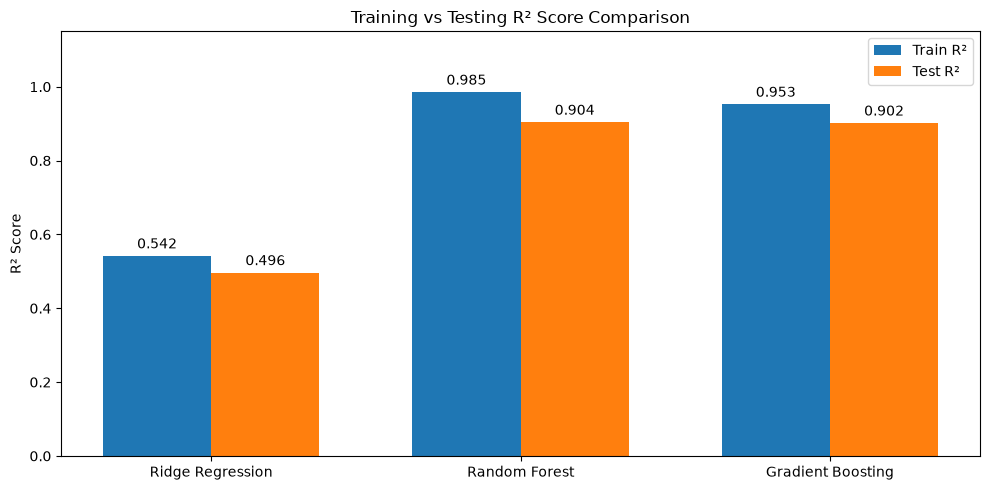

In [33]:
# Bar Chart: Train R² vs Test R²
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(perf_df['Model']))
width = 0.35
rects1 = ax.bar(x - width/2, perf_df['train r2'], width, label='Train R²', color='#1f77b4')
rects2 = ax.bar(x + width/2, perf_df['test r2'], width, label='Test R²', color='#ff7f0e')
ax.set_ylabel('R² Score')
ax.set_title('Training vs Testing R² Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(perf_df['Model'])
ax.set_ylim(0, 1.15)
ax.legend()
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')
plt.tight_layout()
plt.show()

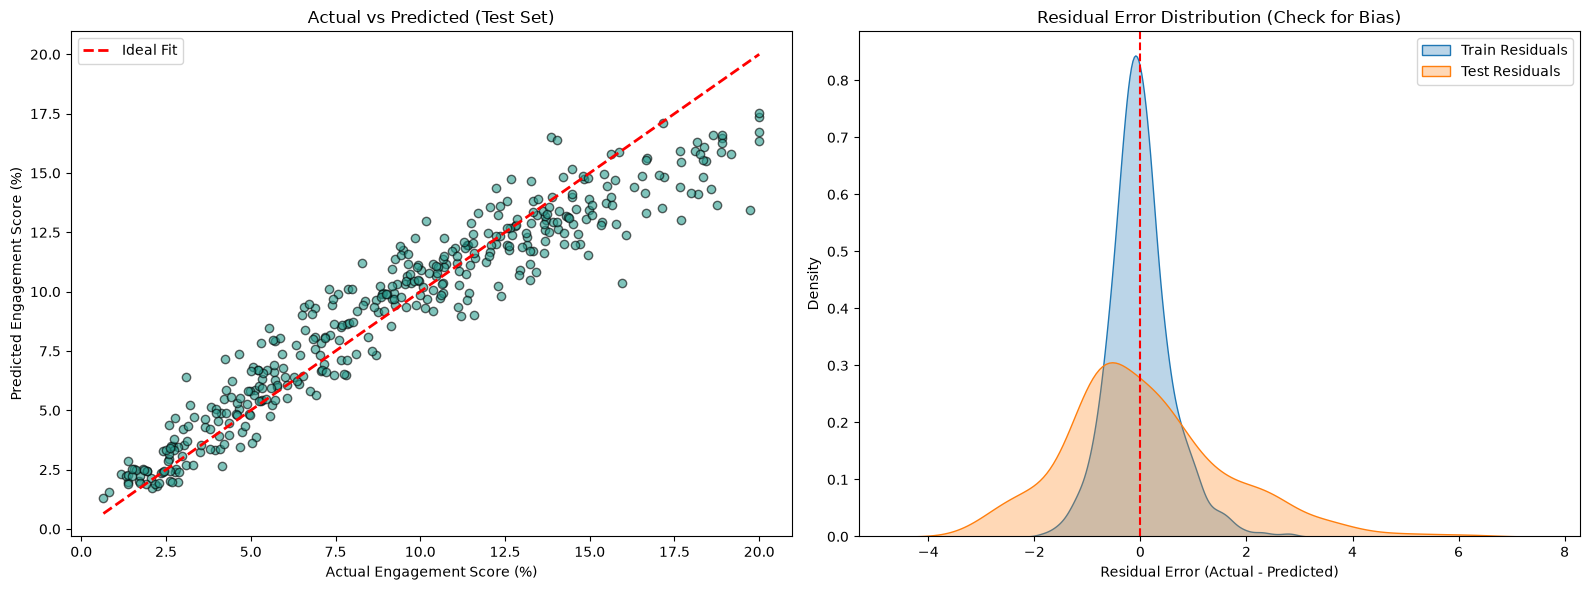

In [35]:
# Residual Diagnostics & Actual vs Predicted
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Actual vs Predicted Scatter Plot\n",
axes[0].scatter(y_test, y_test_pred, alpha=0.6, color='#2a9d8f', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
axes[0].set_xlabel('Actual Engagement Score (%)')
axes[0].set_ylabel('Predicted Engagement Score (%)')
axes[0].set_title('Actual vs Predicted (Test Set)')
axes[0].legend()

# 2. Residual Error Distribution\n",
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred
sns.kdeplot(train_residuals, ax=axes[1], label='Train Residuals', color='#1f77b4', fill=True, alpha=0.3)
sns.kdeplot(test_residuals, ax=axes[1], label='Test Residuals', color='#ff7f0e', fill=True, alpha=0.3)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual Error (Actual - Predicted)')
axes[1].set_ylabel('Density')
axes[1].set_title('Residual Error Distribution (Check for Bias)')
axes[1].legend()
plt.tight_layout()
plt.show()